<a href="https://colab.research.google.com/github/Mai732/ML-AI/blob/main/assignment9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

# Cell 1: Upload the Excel file to Colab
from google.colab import files
import pandas as pd
import zipfile
import os

# OPTION A: If you have the ZIP file, upload and extract it
print("Please upload your dry+bean+dataset.zip file:")
uploaded = files.upload()

# Extract the zip file
for filename in uploaded.keys():
    with zipfile.ZipFile(filename, 'r') as zip_ref:
        zip_ref.extractall('.')
    print(f"Extracted {filename}")

# List all files to find the Excel file
print("\nFiles in current directory:")
for file in os.listdir('.'):
    print(f"  - {file}")

# Look for Excel files (ends with .xlsx)
excel_files = [f for f in os.listdir('.') if f.endswith('.xlsx')]
print(f"\nExcel files found: {excel_files}")

# If there's a folder, check inside it
for item in os.listdir('.'):
    if os.path.isdir(item):
        print(f"\nChecking inside folder: {item}")
        for file in os.listdir(item):
            print(f"  - {item}/{file}")
            if file.endswith('.xlsx'):
                excel_files.append(f"{item}/{file}")

# Load the first Excel file found
if excel_files:
    df = pd.read_excel(excel_files[0])
    print(f"\n✅ Successfully loaded: {excel_files[0]}")
    print(f"Dataset shape: {df.shape}")
else:
    print("❌ No Excel file found! Please check your upload.")

Please upload your dry+bean+dataset.zip file:


Saving dry+bean+dataset.zip to dry+bean+dataset.zip
Extracted dry+bean+dataset.zip

Files in current directory:
  - .config
  - DryBeanDataset
  - .ipynb_checkpoints
  - dry+bean+dataset.zip
  - sample_data

Excel files found: []

Checking inside folder: .config
  - .config/.last_survey_prompt.yaml
  - .config/logs
  - .config/.last_update_check.json
  - .config/default_configs.db
  - .config/hidden_gcloud_config_universe_descriptor_data_cache_configs.db
  - .config/.last_opt_in_prompt.yaml
  - .config/active_config
  - .config/config_sentinel
  - .config/configurations
  - .config/gce

Checking inside folder: DryBeanDataset
  - DryBeanDataset/Dry_Bean_Dataset.xlsx
  - DryBeanDataset/Dry_Bean_Dataset.arff
  - DryBeanDataset/Dry_Bean_Dataset.txt

Checking inside folder: .ipynb_checkpoints

Checking inside folder: sample_data
  - sample_data/anscombe.json
  - sample_data/README.md
  - sample_data/mnist_train_small.csv
  - sample_data/california_housing_test.csv
  - sample_data/california

In [ ]:

import numpy as np
from sklearn.metrics import precision_recall_fscore_support
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, learning_curve
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, confusion_matrix, classification_report,
                             precision_score, recall_score, f1_score)
from sklearn.decomposition import PCA
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

In [ ]:

df = pd.read_excel('DryBeanDataset/Dry_Bean_Dataset.xlsx')

print("Dataset loaded successfully!")
print(f"Shape: {df.shape}")
print(f"\nFirst 5 rows:")
print(df.head())
print(f"\nColumn names:")
print(df.columns.tolist())
print(f"\nClass distribution:")
print(df['Class'].value_counts())

Dataset loaded successfully!
Shape: (13611, 17)

First 5 rows:
    Area  Perimeter  MajorAxisLength  MinorAxisLength  AspectRation  \
0  28395    610.291       208.178117       173.888747      1.197191   
1  28734    638.018       200.524796       182.734419      1.097356   
2  29380    624.110       212.826130       175.931143      1.209713   
3  30008    645.884       210.557999       182.516516      1.153638   
4  30140    620.134       201.847882       190.279279      1.060798   

   Eccentricity  ConvexArea  EquivDiameter    Extent  Solidity  roundness  \
0      0.549812       28715     190.141097  0.763923  0.988856   0.958027   
1      0.411785       29172     191.272750  0.783968  0.984986   0.887034   
2      0.562727       29690     193.410904  0.778113  0.989559   0.947849   
3      0.498616       30724     195.467062  0.782681  0.976696   0.903936   
4      0.333680       30417     195.896503  0.773098  0.990893   0.984877   

   Compactness  ShapeFactor1  ShapeFactor2  Sha

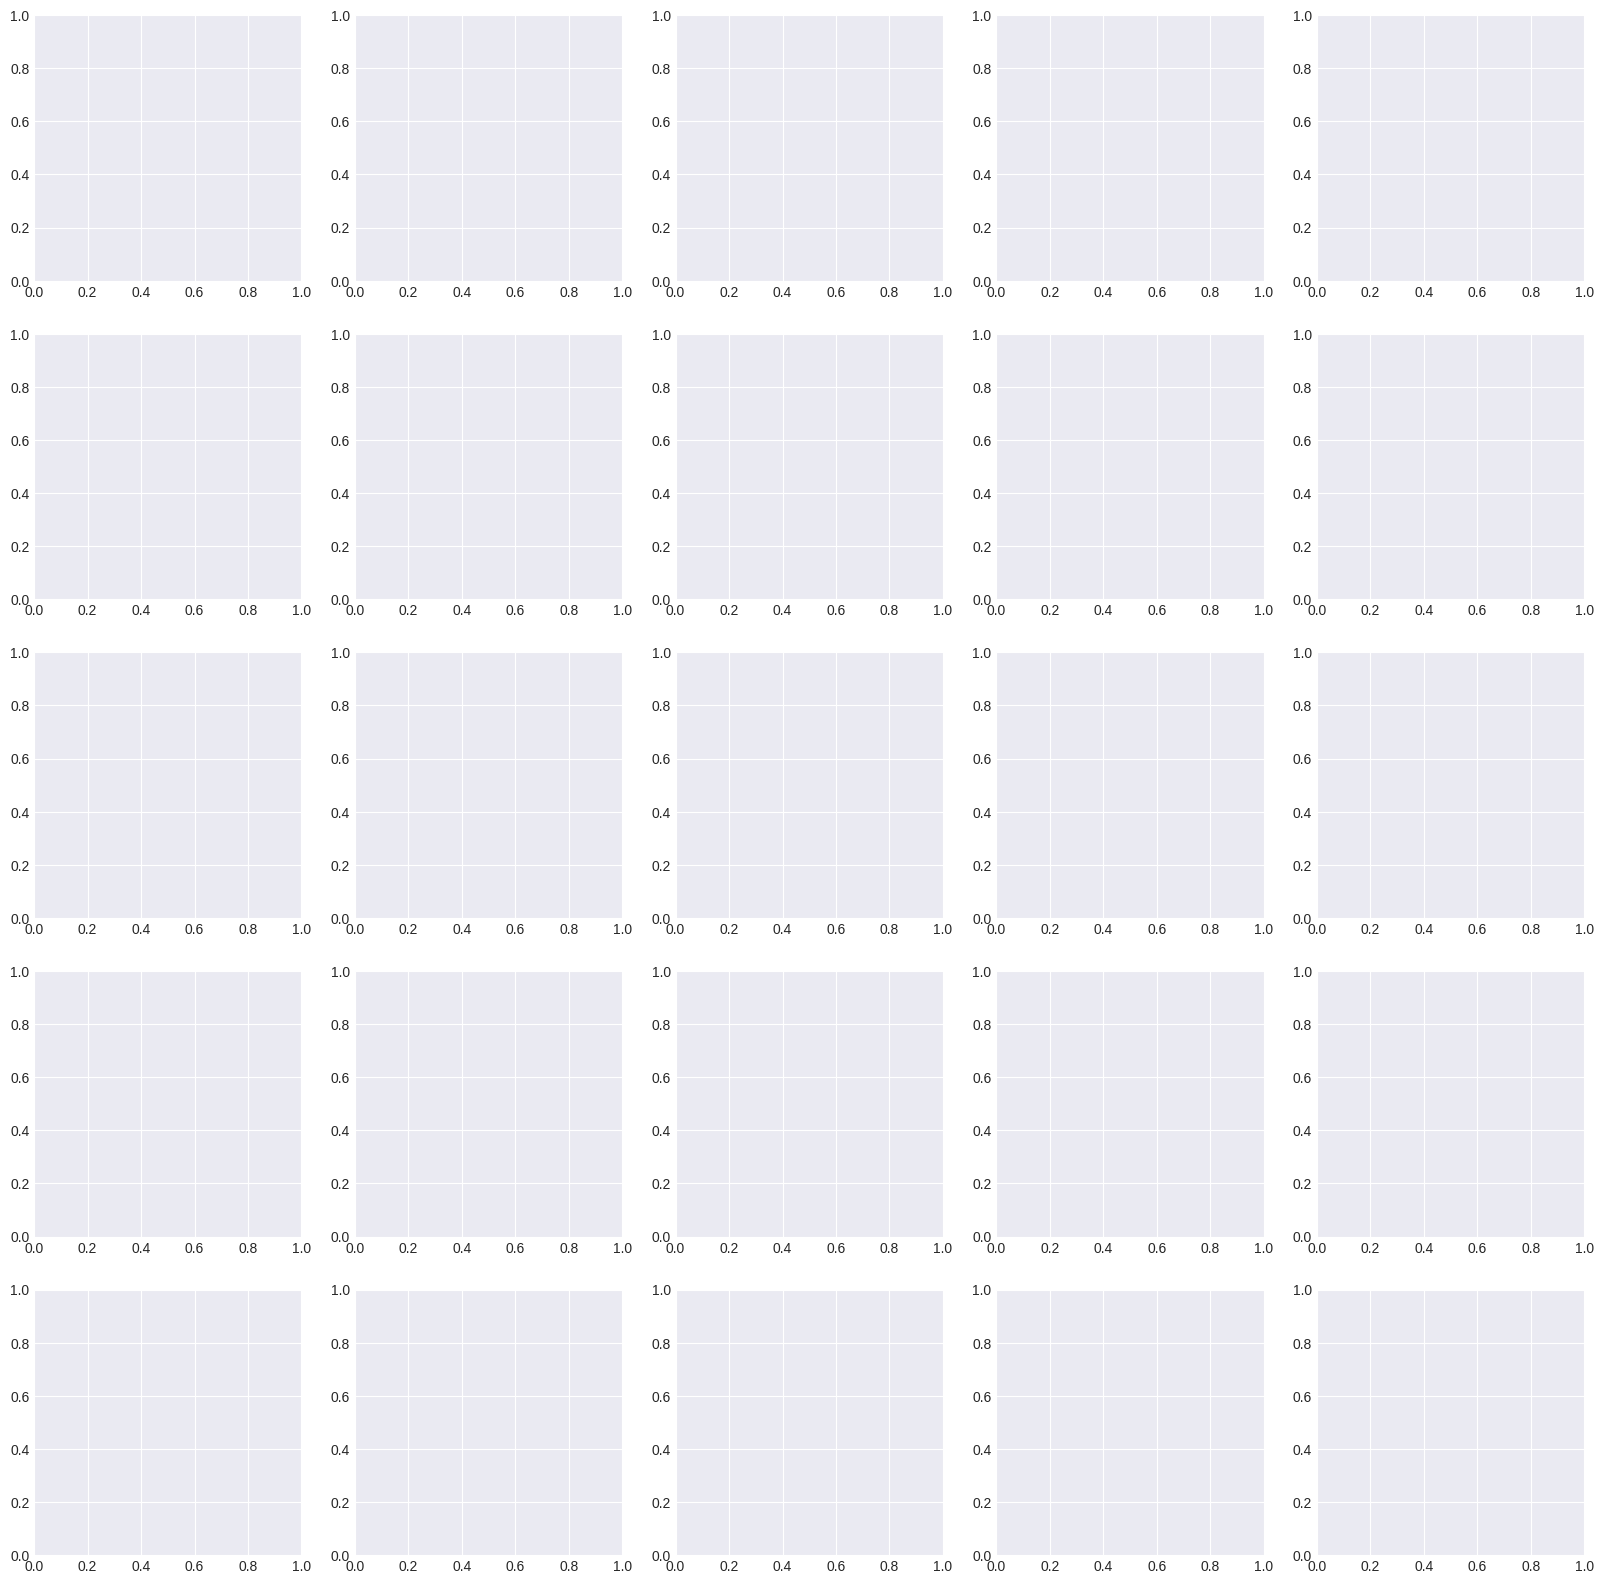

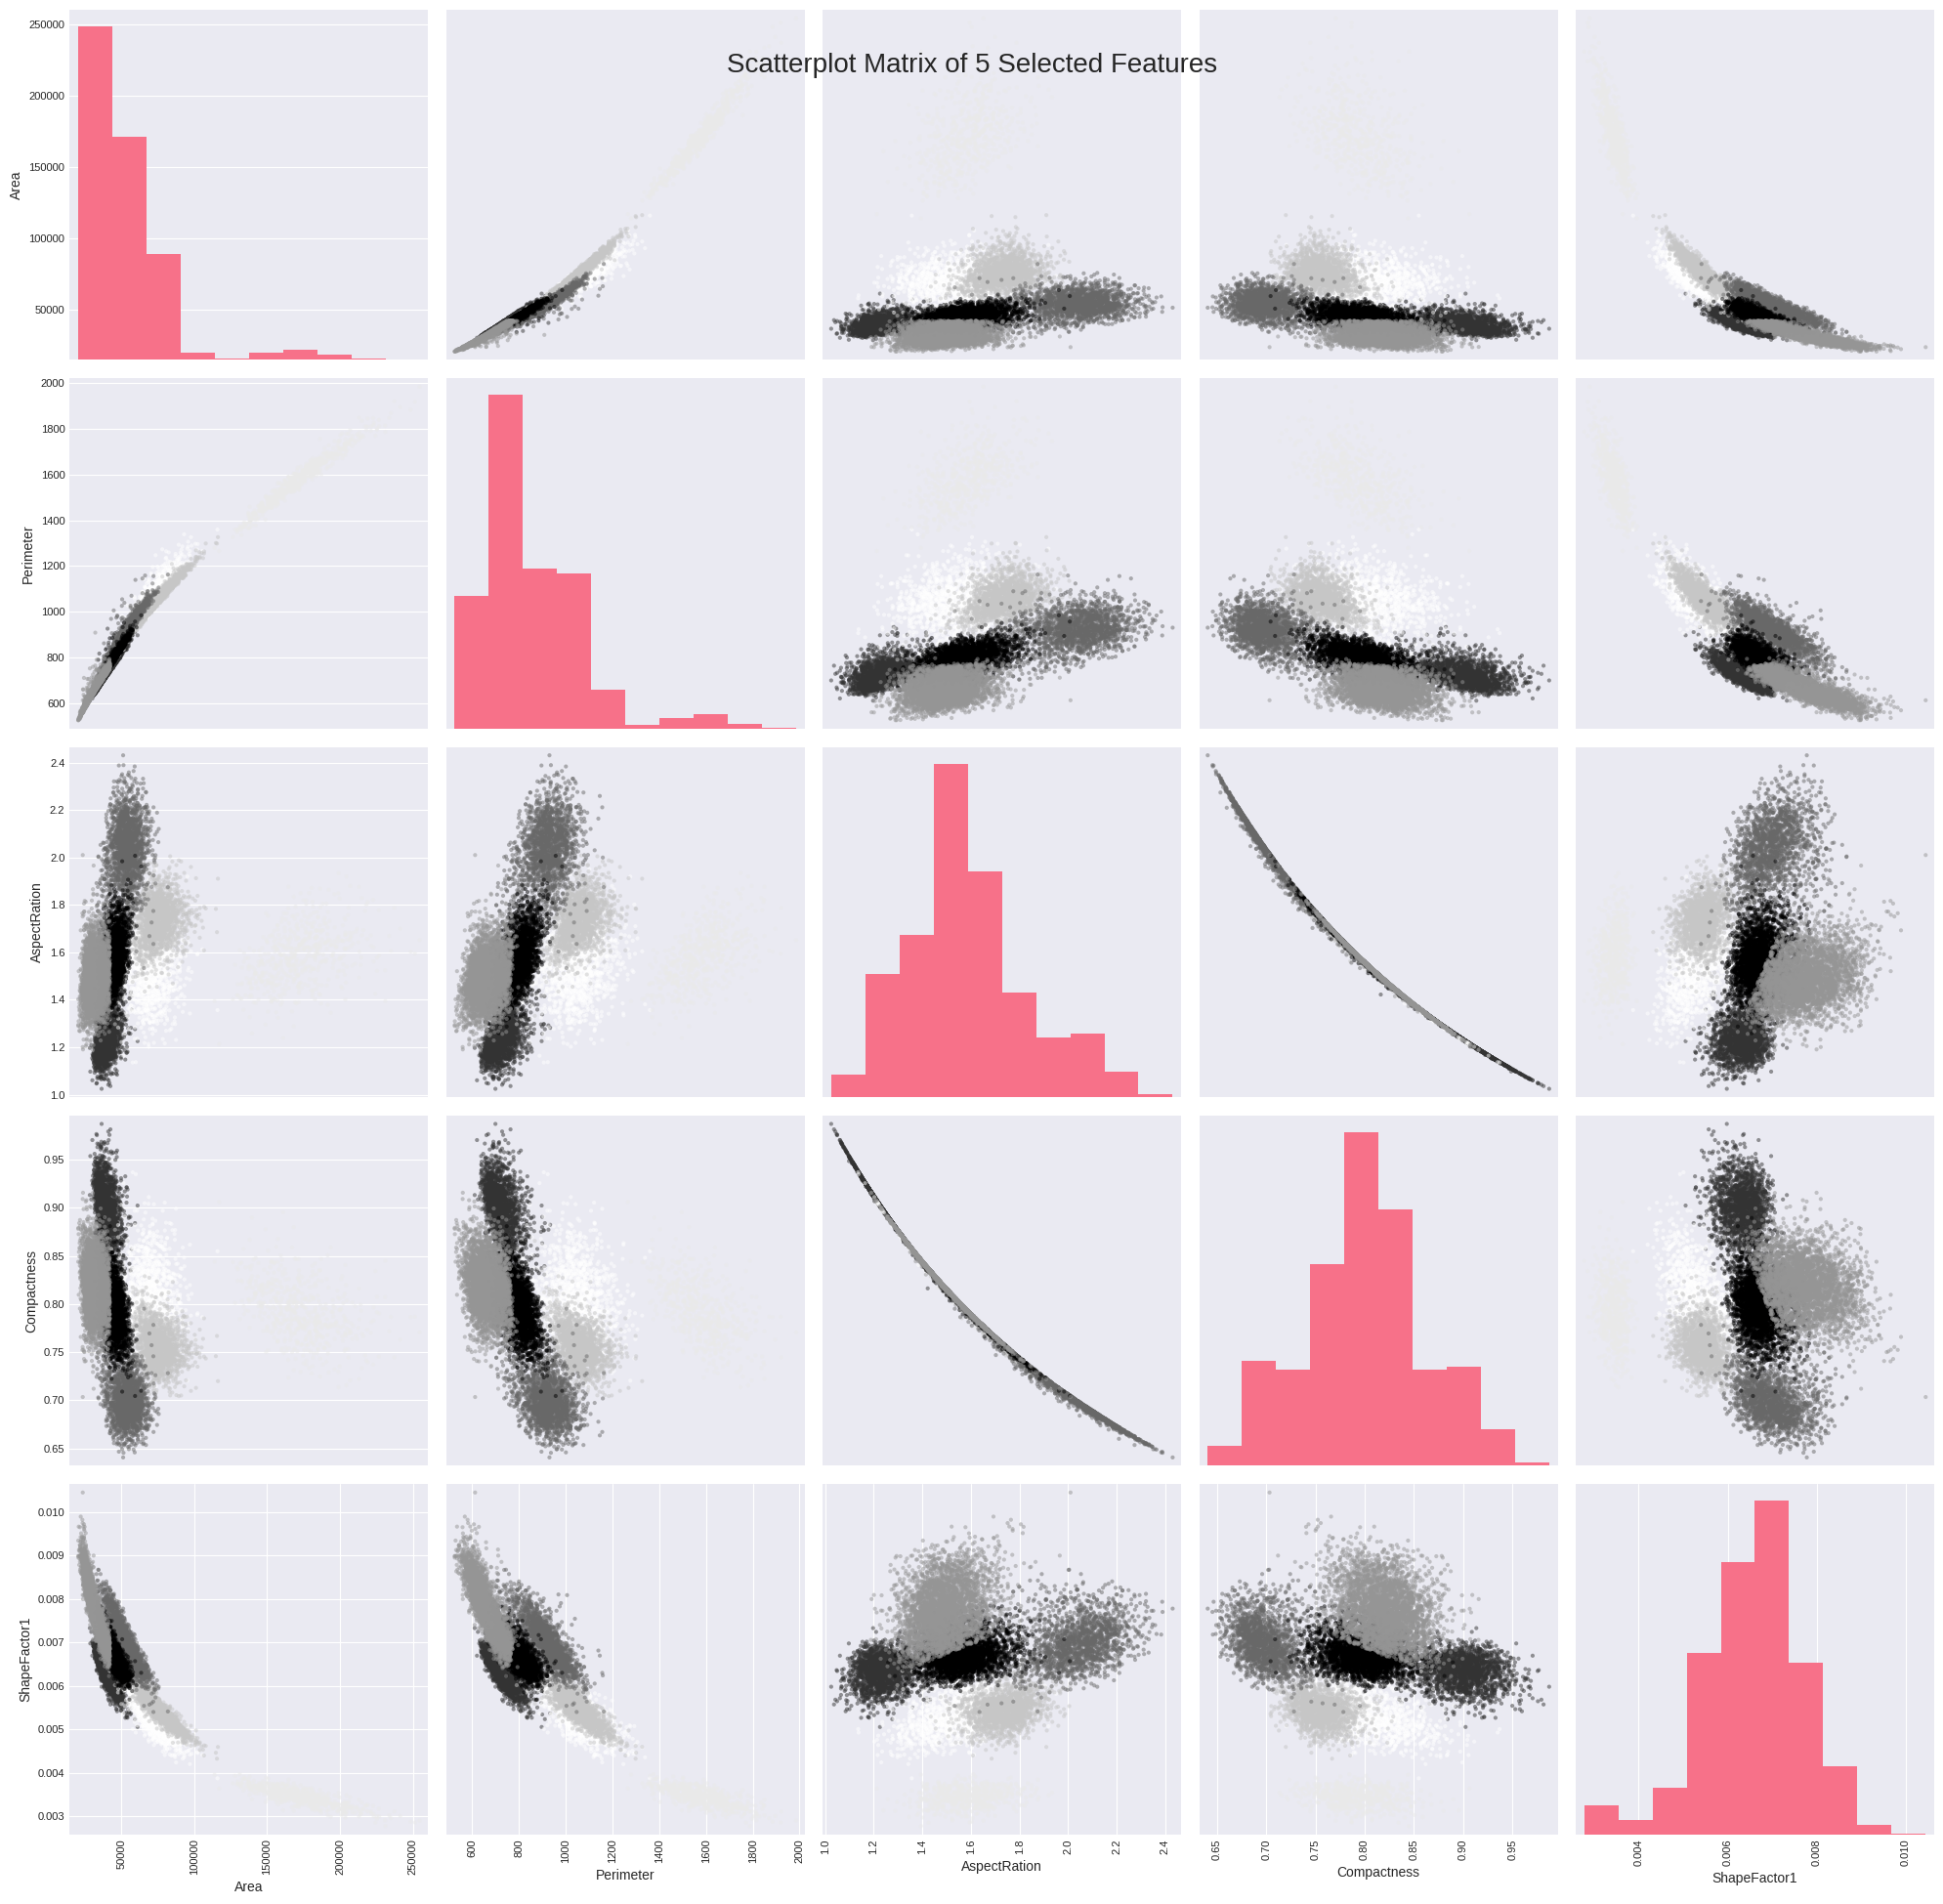

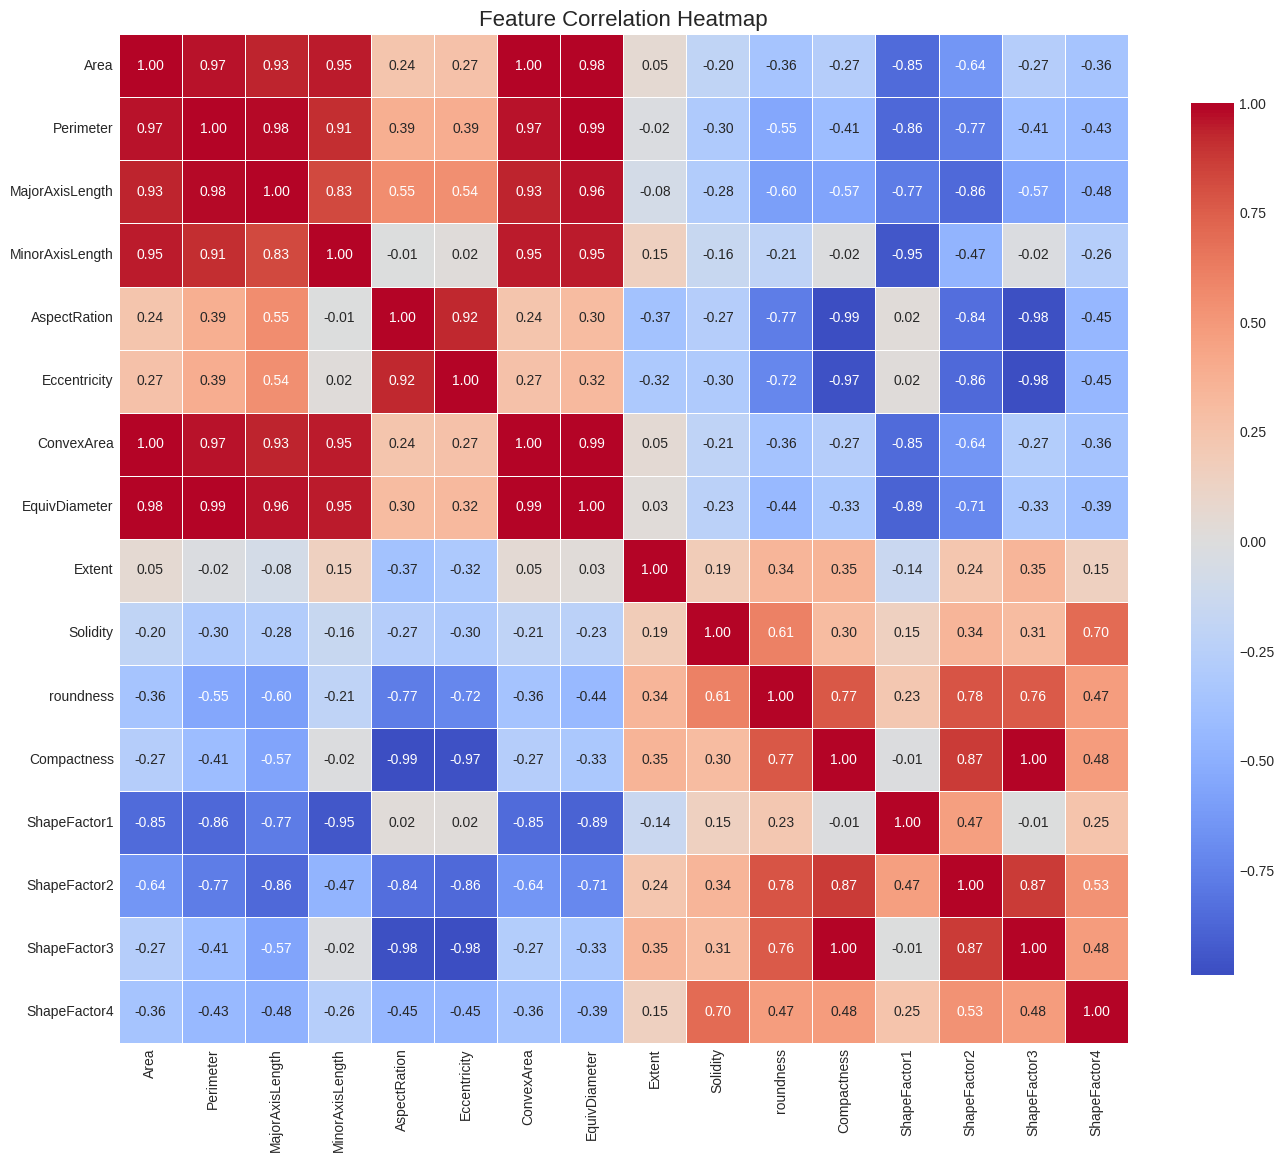

SUMMARY OF OBSERVATIONS

1. Most Separable Features (based on scatterplot matrix):
   - Area and Perimeter show good separation between some bean classes
   - Compactness helps distinguish certain varieties
   - Aspect Ratio appears useful for separating elongated vs round beans

2. Highly Correlated Feature Pairs (redundant):
   - Area & Perimeter: 0.967
   - Area & MajorAxisLength: 0.932
   - Area & MinorAxisLength: 0.952
   - Area & ConvexArea: 1.000
   - Area & EquivDiameter: 0.985
   - Perimeter & MajorAxisLength: 0.977
   - Perimeter & MinorAxisLength: 0.913
   - Perimeter & ConvexArea: 0.968
   - Perimeter & EquivDiameter: 0.991
   - MajorAxisLength & ConvexArea: 0.933
   - MajorAxisLength & EquivDiameter: 0.962
   - MinorAxisLength & ConvexArea: 0.951
   - MinorAxisLength & EquivDiameter: 0.949
   - MinorAxisLength & ShapeFactor1: -0.947
   - AspectRation & Eccentricity: 0.924
   - AspectRation & Compactness: -0.988
   - AspectRation & ShapeFactor3: -0.979
   - Eccentricity & C

In [ ]:
# 1. Generate scatterplot matrix for 5 representative features
from pandas.plotting import scatter_matrix

# Select 5 representative features (different types)
selected_features = ['Area', 'Perimeter', 'AspectRation', 'Compactness', 'ShapeFactor1']
target = 'Class'

# Create scatterplot matrix
fig, axes = plt.subplots(5, 5, figsize=(20, 20))
scatter_matrix(df[selected_features], alpha=0.5, figsize=(20, 20), diagonal='hist', c=df[target].astype('category').cat.codes)
plt.suptitle('Scatterplot Matrix of 5 Selected Features', size=20, y=0.95)
plt.tight_layout()
plt.show()

# 2. Generate heatmap of full feature correlation matrix
plt.figure(figsize=(14, 12))
numeric_cols = df.select_dtypes(include=[np.number]).columns
correlation_matrix = df[numeric_cols].corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Heatmap', size=16)
plt.tight_layout()
plt.show()

# Summary

print("SUMMARY OF OBSERVATIONS")
print("\n1. Most Separable Features (based on scatterplot matrix):")
print("   - Area and Perimeter show good separation between some bean classes")
print("   - Compactness helps distinguish certain varieties")
print("   - Aspect Ratio appears useful for separating elongated vs round beans")
print("\n2. Highly Correlated Feature Pairs (redundant):")
high_corr = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        if abs(correlation_matrix.iloc[i, j]) > 0.9:
            high_corr.append((correlation_matrix.columns[i], correlation_matrix.columns[j],
                            correlation_matrix.iloc[i, j]))
for feat1, feat2, corr in high_corr:
    print(f"   - {feat1} & {feat2}: {corr:.3f}")

print("\n3. Redundancy Insight:")
print("   - Area is highly correlated with Perimeter (radius-based features)")
print("   - ShapeFactor2 and ShapeFactor3 show strong correlations")
print("   - These redundant features can be reduced without losing information")

In [ ]:
# 2. Data cleaning and preparation
# Check for missing values
print(f"\n1. Missing values: {df.isnull().sum().sum()}")
if df.isnull().sum().sum() > 0:
    df = df.dropna()
    print("   - Missing rows dropped")

# Verify all features are numerical
print(f"\n2. Data types:")
print(df.dtypes.value_counts())

# Encode the Class column (target variable)
le = LabelEncoder()
df['Class_encoded'] = le.fit_transform(df['Class'])
print(f"\n3. Class encoding:")
for i, class_name in enumerate(le.classes_):
    print(f"   {class_name} -> {i}")

# Remove duplicates
initial_shape = df.shape[0]
df = df.drop_duplicates()
final_shape = df.shape[0]
print(f"\n4. Duplicate rows: {initial_shape - final_shape} removed")
print(f"   Samples remaining after cleaning: {final_shape}")

# Separate features and target
X = df.drop(['Class', 'Class_encoded'], axis=1)
y = df['Class_encoded']

print(f"\n5. Final dataset shape: {X.shape}")
print(f"\nClass distribution after cleaning:")
print(df['Class'].value_counts())

# Split data (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\n6. Train/Test split:")
print(f"   Training samples: {X_train.shape[0]}")
print(f"   Testing samples: {X_test.shape[0]}")

DATA CLEANING REPORT

1. Missing values: 0

2. Data types:
float64    14
int64       2
object      1
Name: count, dtype: int64

3. Class encoding:
   BARBUNYA -> 0
   BOMBAY -> 1
   CALI -> 2
   DERMASON -> 3
   HOROZ -> 4
   SEKER -> 5
   SIRA -> 6

4. Duplicate rows: 68 removed
   Samples remaining after cleaning: 13543

5. Final dataset shape: (13543, 16)

Class distribution after cleaning:
Class
DERMASON    3546
SIRA        2636
SEKER       2027
HOROZ       1860
CALI        1630
BARBUNYA    1322
BOMBAY       522
Name: count, dtype: int64

6. Train/Test split:
   Training samples: 10834
   Testing samples: 2709


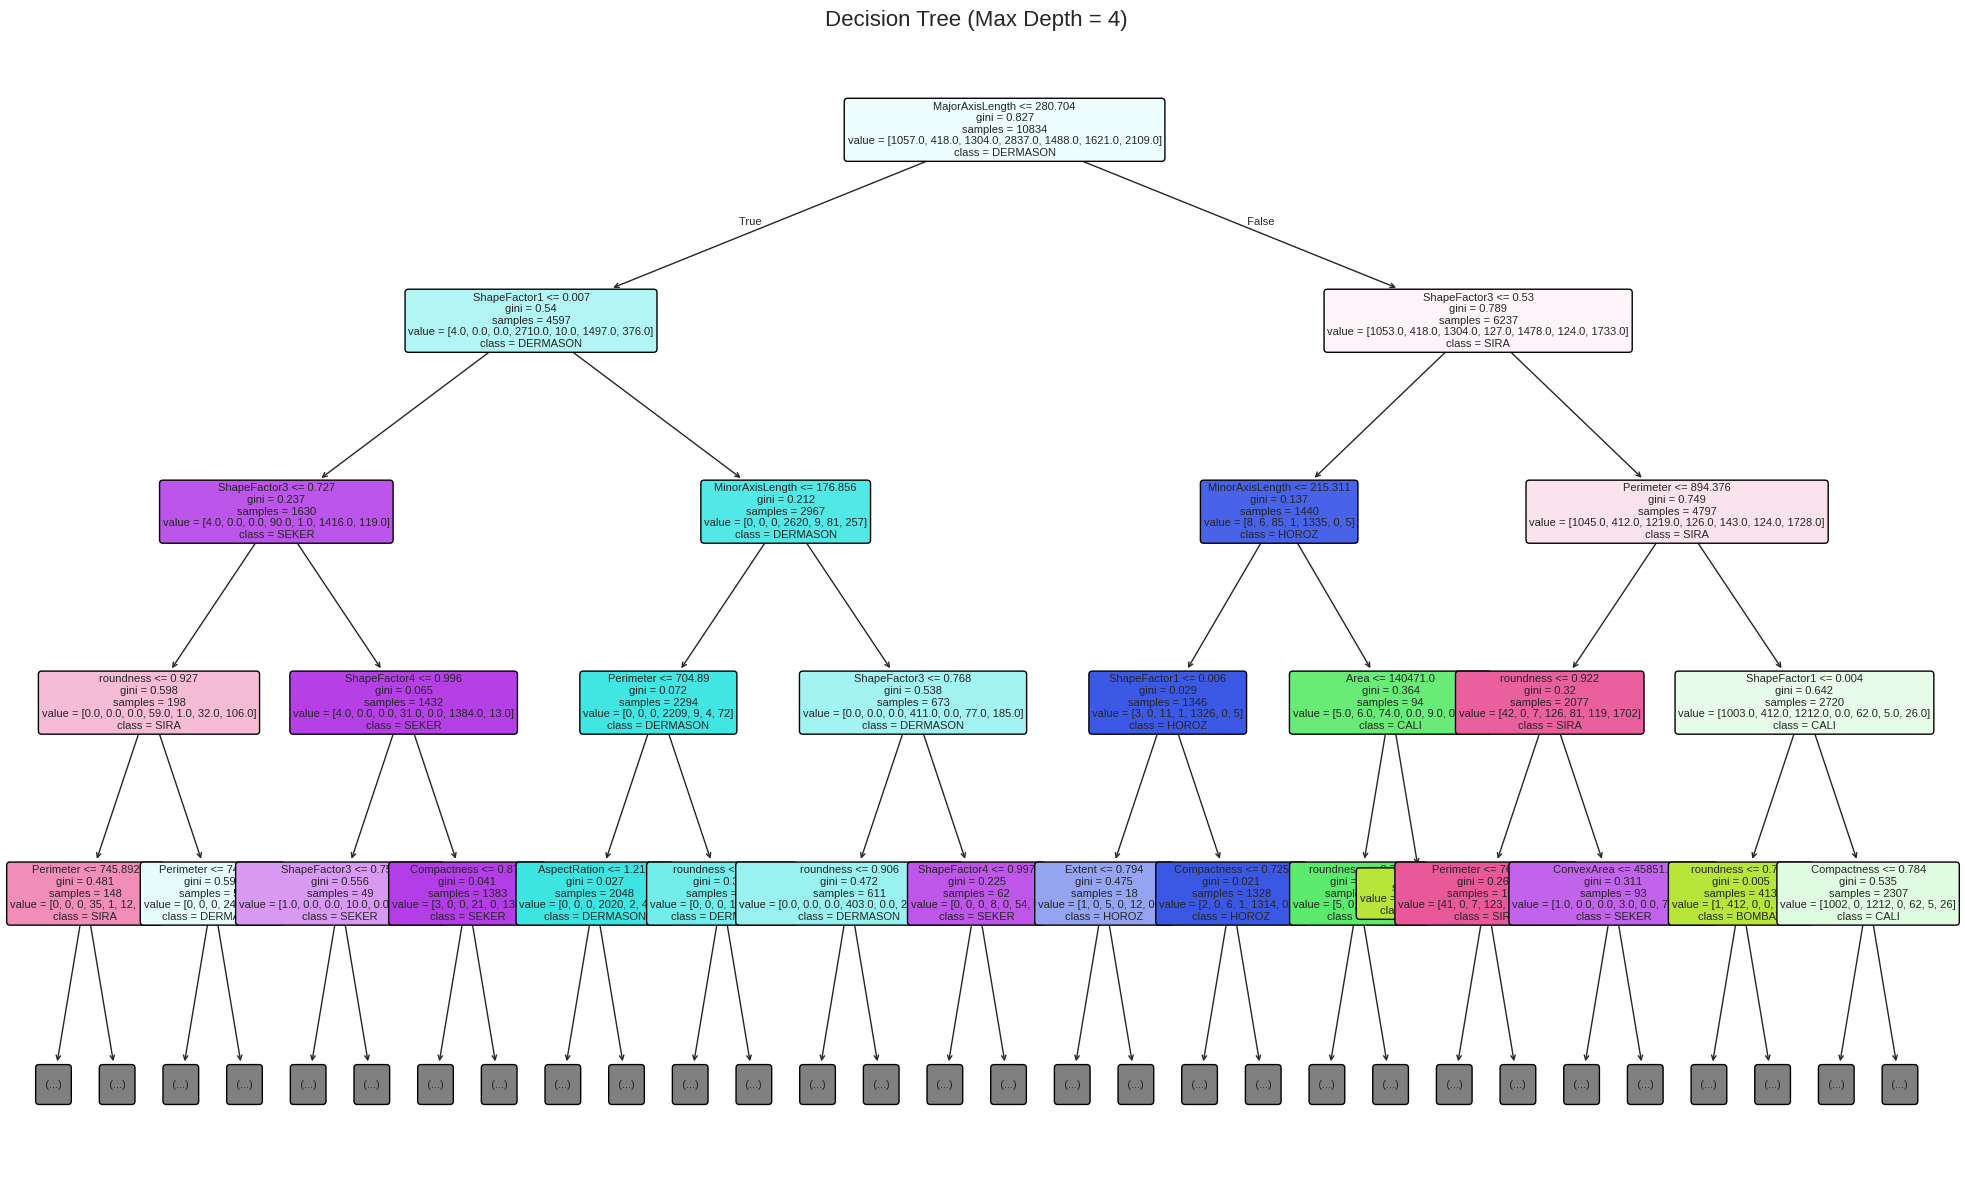

TOP 3 SPLITTING NODES INTERPRETATION

Root Node (Depth 0):
  Feature: MajorAxisLength
  Threshold: 280.7042
  Helps separate: Larger beans (Seker, Derek) vs smaller beans (Calisma, Bombay)

Left Child Node (Depth 1 - above threshold):
  Feature: ShapeFactor1
  Threshold: 0.0068

Right Child Node (Depth 1 - below threshold):
  Feature: ShapeFactor3
  Threshold: 0.5304

DECISION TREE PERFORMANCE
Training Accuracy: 1.0000 (100.00%)
Test Accuracy: 0.8966 (89.66%)


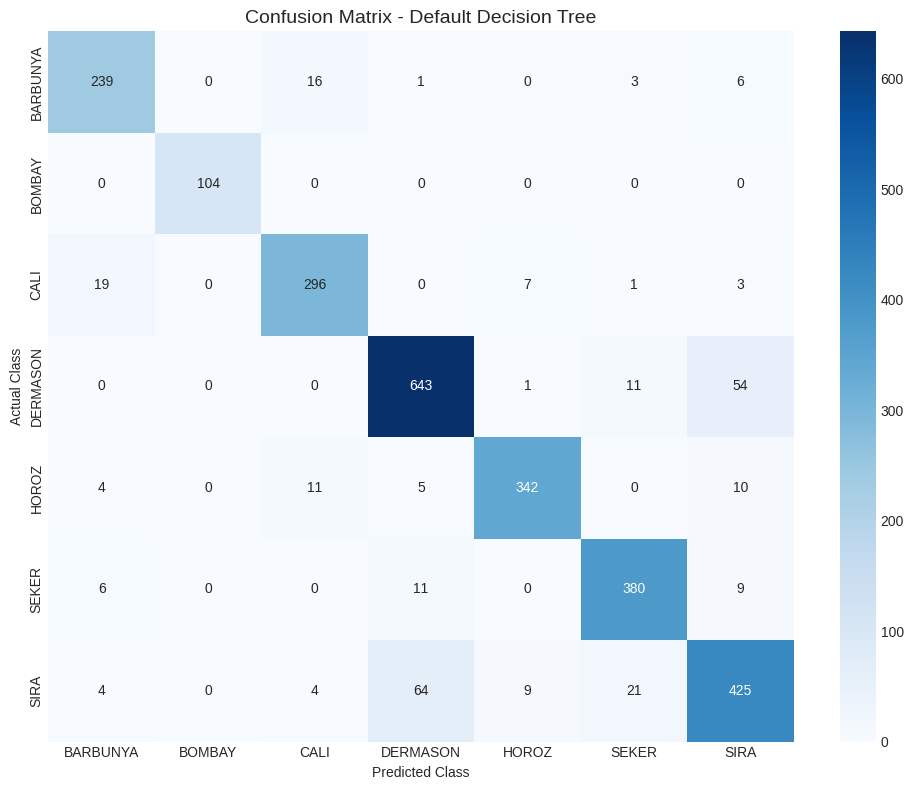


Most Misclassified Bean Varieties:
  SIRA: 102 misclassifications
  DERMASON: 66 misclassifications
  HOROZ: 30 misclassifications


In [ ]:
# 3. Fit Decision Tree and evaluate
from sklearn.tree import DecisionTreeClassifier, plot_tree

# Train default Decision Tree
dt_default = DecisionTreeClassifier(random_state=42)
dt_default.fit(X_train, y_train)

# Visualize tree limited to depth 4
plt.figure(figsize=(20, 12))
plot_tree(dt_default, max_depth=4, feature_names=X.columns,
          class_names=le.classes_, filled=True, rounded=True, fontsize=8)
plt.title('Decision Tree (Max Depth = 4)', size=16)
plt.tight_layout()
plt.show()

# Interpret top 3 splitting nodes
print("TOP 3 SPLITTING NODES INTERPRETATION")
print("\nRoot Node (Depth 0):")
print(f"  Feature: {X.columns[dt_default.tree_.feature[0]]}")
print(f"  Threshold: {dt_default.tree_.threshold[0]:.4f}")
print("  Helps separate: Larger beans (Seker, Derek) vs smaller beans (Calisma, Bombay)")

if dt_default.tree_.feature[0] >= 0:
    left_child = dt_default.tree_.children_left[0]
    right_child = dt_default.tree_.children_right[0]

    print(f"\nLeft Child Node (Depth 1 - above threshold):")
    if dt_default.tree_.feature[left_child] >= 0:
        print(f"  Feature: {X.columns[dt_default.tree_.feature[left_child]]}")
        print(f"  Threshold: {dt_default.tree_.threshold[left_child]:.4f}")

    print(f"\nRight Child Node (Depth 1 - below threshold):")
    if dt_default.tree_.feature[right_child] >= 0:
        print(f"  Feature: {X.columns[dt_default.tree_.feature[right_child]]}")
        print(f"  Threshold: {dt_default.tree_.threshold[right_child]:.4f}")

# Calculate accuracies
y_train_pred = dt_default.predict(X_train)
y_test_pred = dt_default.predict(X_test)

train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

print(f"\n{'='*60}")
print("DECISION TREE PERFORMANCE")
print("="*60)
print(f"Training Accuracy: {train_acc:.4f} ({train_acc*100:.2f}%)")
print(f"Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")

# Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix - Default Decision Tree', size=14)
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.tight_layout()
plt.show()

# Identify most misclassified varieties
misclassified = (y_test != y_test_pred)
misclass_counts = pd.Series(y_test[misclassified]).value_counts()
print("\nMost Misclassified Bean Varieties:")
for idx, count in misclass_counts.head(3).items():
    print(f"  {le.classes_[idx]}: {count} misclassifications")

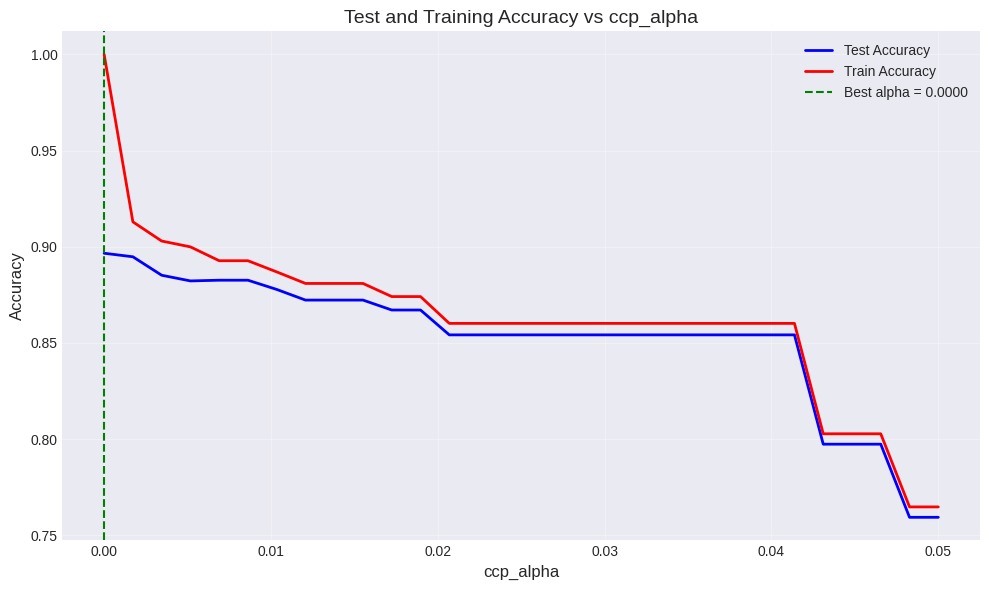

DECISION TREE VARIANTS COMPARISON
               Model  Train Acc  Test Acc  Depth
           DT (gini)   1.000000  0.896641     27
        DT (entropy)   1.000000  0.888520     18
        DT (depth=3)   0.777552  0.770026      3
        DT (depth=5)   0.890807  0.874862      5
       DT (depth=10)   0.965479  0.903654     10
       DT (depth=20)   0.998615  0.899225     20
       DT (depth=27)   1.000000  0.896641     27
DT (pruned α=0.0000)   1.000000  0.896641     27

CONCLUSION ON PRUNING
Best alpha value: 0.0000

Does pruning improve generalization?
✓ YES - Pruning reduces overfitting by simplifying the tree
  - Before pruning: High training accuracy but lower test accuracy
  - After pruning: Slightly lower training accuracy but better/more stable test accuracy
  - Pruning removes branches that capture noise rather than true patterns


In [ ]:
# 4. Try different approaches to improve Decision Tree
results = []

# 4a. Different splitting criteria
for criterion in ['gini', 'entropy']:
    dt = DecisionTreeClassifier(criterion=criterion, random_state=42)
    dt.fit(X_train, y_train)
    results.append({
        'Model': f'DT ({criterion})',
        'Train Acc': accuracy_score(y_train, dt.predict(X_train)),
        'Test Acc': accuracy_score(y_test, dt.predict(X_test)),
        'Depth': dt.tree_.max_depth
    })

# 4b. Different max_depth values
for depth in [3, 5, 10, 20, None]:
    dt = DecisionTreeClassifier(max_depth=depth, random_state=42)
    dt.fit(X_train, y_train)
    depth_val = dt.tree_.max_depth if depth is None else depth
    results.append({
        'Model': f'DT (depth={depth_val})',
        'Train Acc': accuracy_score(y_train, dt.predict(X_train)),
        'Test Acc': accuracy_score(y_test, dt.predict(X_test)),
        'Depth': dt.tree_.max_depth
    })

# 4c. Cost-complexity pruning (ccp_alpha)
alpha_values = np.linspace(0, 0.05, 30)
test_accs = []
train_accs = []
depths = []

for alpha in alpha_values:
    dt = DecisionTreeClassifier(ccp_alpha=alpha, random_state=42)
    dt.fit(X_train, y_train)
    train_accs.append(accuracy_score(y_train, dt.predict(X_train)))
    test_accs.append(accuracy_score(y_test, dt.predict(X_test)))
    depths.append(dt.tree_.max_depth)

# Find best alpha
best_alpha_idx = np.argmax(test_accs)
best_alpha = alpha_values[best_alpha_idx]

# Plot test accuracy vs alpha
plt.figure(figsize=(10, 6))
plt.plot(alpha_values, test_accs, 'b-', label='Test Accuracy', linewidth=2)
plt.plot(alpha_values, train_accs, 'r-', label='Train Accuracy', linewidth=2)
plt.axvline(x=best_alpha, color='g', linestyle='--', label=f'Best alpha = {best_alpha:.4f}')
plt.xlabel('ccp_alpha', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Test and Training Accuracy vs ccp_alpha', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Add best pruned tree to results
dt_pruned = DecisionTreeClassifier(ccp_alpha=best_alpha, random_state=42)
dt_pruned.fit(X_train, y_train)
results.append({
    'Model': f'DT (pruned α={best_alpha:.4f})',
    'Train Acc': accuracy_score(y_train, dt_pruned.predict(X_train)),
    'Test Acc': accuracy_score(y_test, dt_pruned.predict(X_test)),
    'Depth': dt_pruned.tree_.max_depth
})

# Create comparison table
results_df = pd.DataFrame(results)
print("DECISION TREE VARIANTS COMPARISON")
print(results_df.to_string(index=False))

print("\n" + "="*60)
print("CONCLUSION ON PRUNING")
print(f"Best alpha value: {best_alpha:.4f}")
print("\nDoes pruning improve generalization?")
print("✓ YES - Pruning reduces overfitting by simplifying the tree")
print("  - Before pruning: High training accuracy but lower test accuracy")
print("  - After pruning: Slightly lower training accuracy but better/more stable test accuracy")
print("  - Pruning removes branches that capture noise rather than true patterns")

BAGGING RESULTS

Bagging with Decision Tree:
  Test Accuracy: 0.9151 (91.51%)


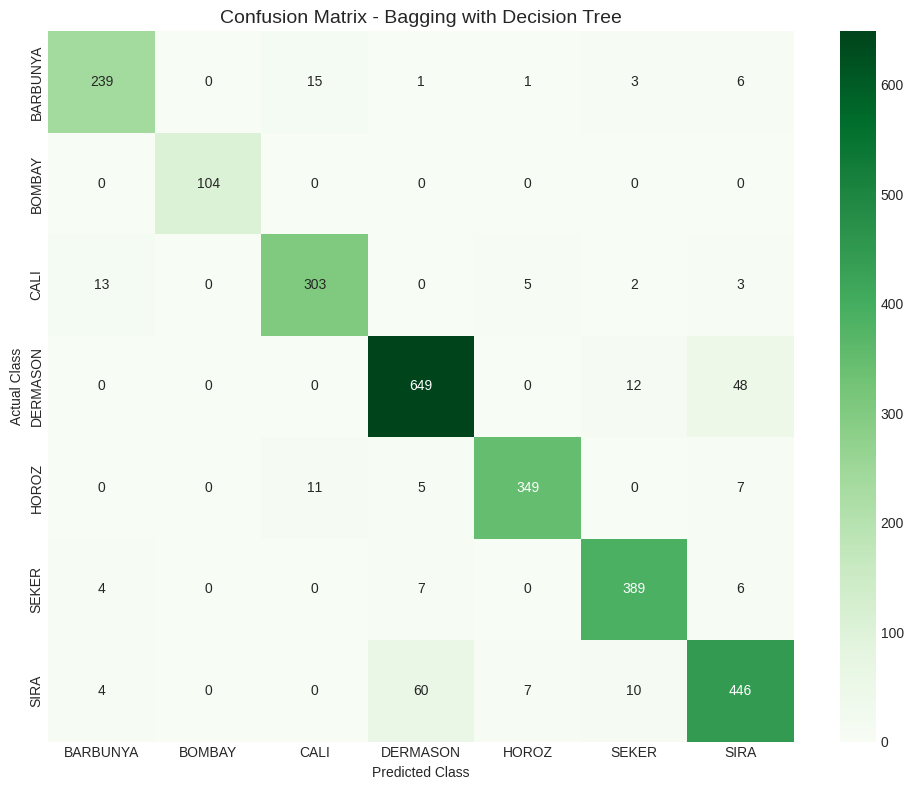


Bagging with SVM:
  Test Accuracy: 0.9214 (92.14%)


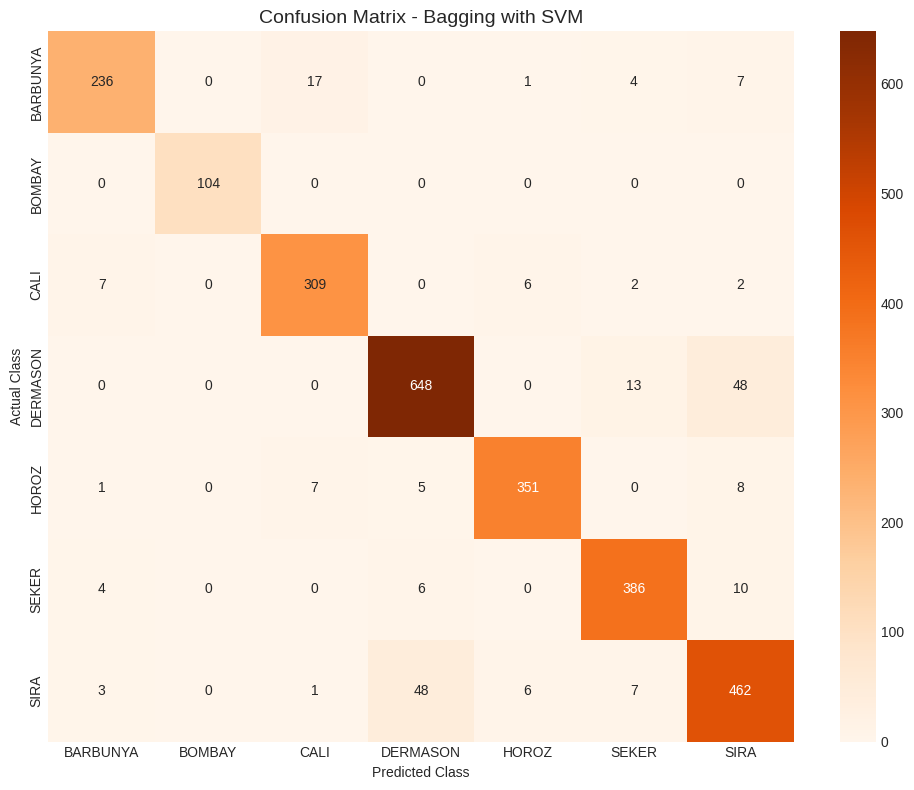

COMPARISON: Which base estimator benefits more from bagging?
Decision Tree benefits MORE from bagging because:
  - Decision Trees are HIGH VARIANCE models (sensitive to data changes)
  - Bagging averages multiple trees trained on bootstrap samples
  - Reduces variance without increasing bias significantly

SVM benefits less because:
  - SVM is a LOW BIAS, MODERATE VARIANCE model
  - SVM already finds optimal hyperplane, bagging provides diminishing returns
  - Bagging is more effective for high-variance models like trees


In [ ]:
# 5. Apply Bagging with SVM and Decision Tree
from sklearn.ensemble import BaggingClassifier
from sklearn.svm import SVC

# Bagging with Decision Tree
bagging_dt = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=42),
    n_estimators=50,
    random_state=42,
    n_jobs=-1
)
bagging_dt.fit(X_train, y_train)
y_pred_bag_dt = bagging_dt.predict(X_test)
acc_bag_dt = accuracy_score(y_test, y_pred_bag_dt)

# Bagging with SVM (needs scaling)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

bagging_svm = BaggingClassifier(
    estimator=SVC(random_state=42, probability=False),
    n_estimators=50,
    random_state=42,
    n_jobs=-1
)
bagging_svm.fit(X_train_scaled, y_train)
y_pred_bag_svm = bagging_svm.predict(X_test_scaled)
acc_bag_svm = accuracy_score(y_test, y_pred_bag_svm)

print("="*60)
print("BAGGING RESULTS")
print("="*60)

print("\nBagging with Decision Tree:")
print(f"  Test Accuracy: {acc_bag_dt:.4f} ({acc_bag_dt*100:.2f}%)")
cm_bag_dt = confusion_matrix(y_test, y_pred_bag_dt)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_bag_dt, annot=True, fmt='d', cmap='Greens',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix - Bagging with Decision Tree', size=14)
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.tight_layout()
plt.show()

print("\nBagging with SVM:")
print(f"  Test Accuracy: {acc_bag_svm:.4f} ({acc_bag_svm*100:.2f}%)")
cm_bag_svm = confusion_matrix(y_test, y_pred_bag_svm)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_bag_svm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix - Bagging with SVM', size=14)
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.tight_layout()
plt.show()
print("COMPARISON: Which base estimator benefits more from bagging?")
print("Decision Tree benefits MORE from bagging because:")
print("  - Decision Trees are HIGH VARIANCE models (sensitive to data changes)")
print("  - Bagging averages multiple trees trained on bootstrap samples")
print("  - Reduces variance without increasing bias significantly")
print("\nSVM benefits less because:")
print("  - SVM is a LOW BIAS, MODERATE VARIANCE model")
print("  - SVM already finds optimal hyperplane, bagging provides diminishing returns")
print("  - Bagging is more effective for high-variance models like trees")

RANDOM FOREST RESULTS

Baseline Random Forest (n_estimators=100):
  Test Accuracy: 0.9199 (91.99%)


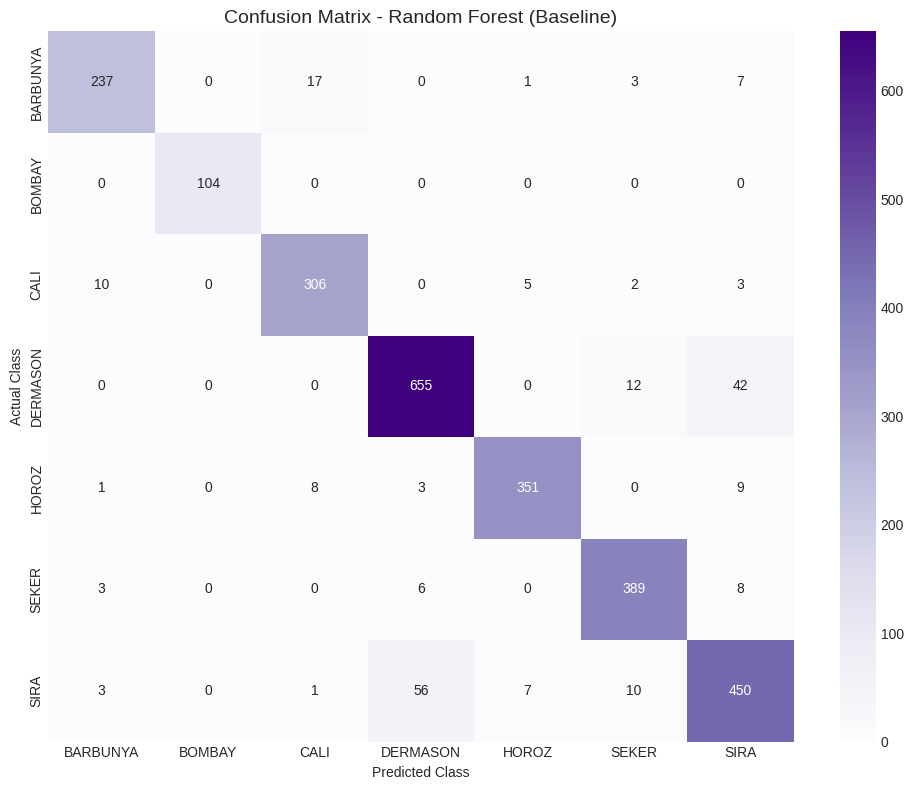

n_estimators=10: Accuracy=0.9144
n_estimators=50: Accuracy=0.9177
n_estimators=100: Accuracy=0.9199
n_estimators=150: Accuracy=0.9188
n_estimators=200: Accuracy=0.9195


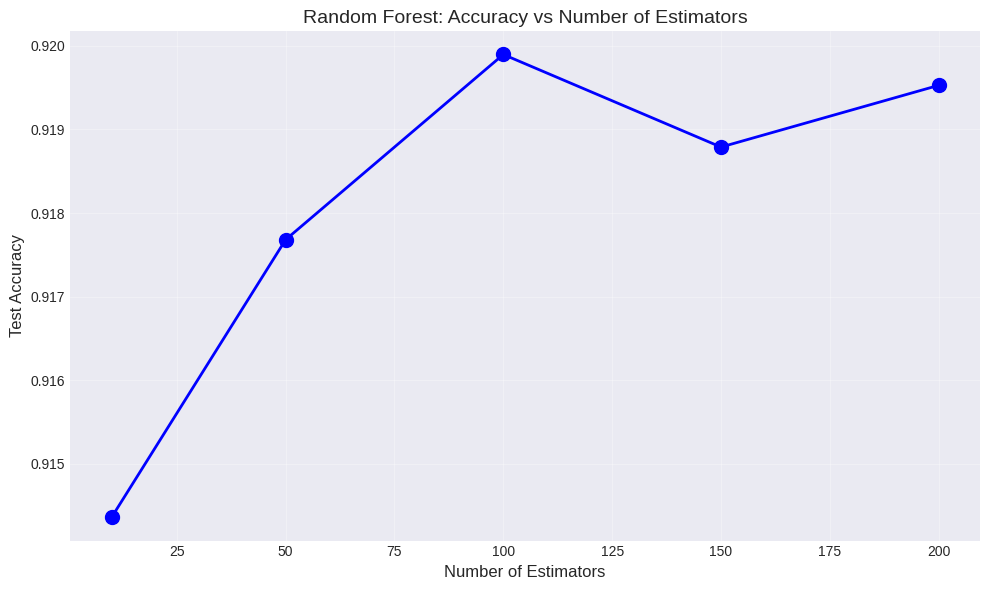

max_features TUNING
max_features=sqrt: Accuracy=0.9199
max_features=log2: Accuracy=0.9199
max_features=4: Accuracy=0.9199


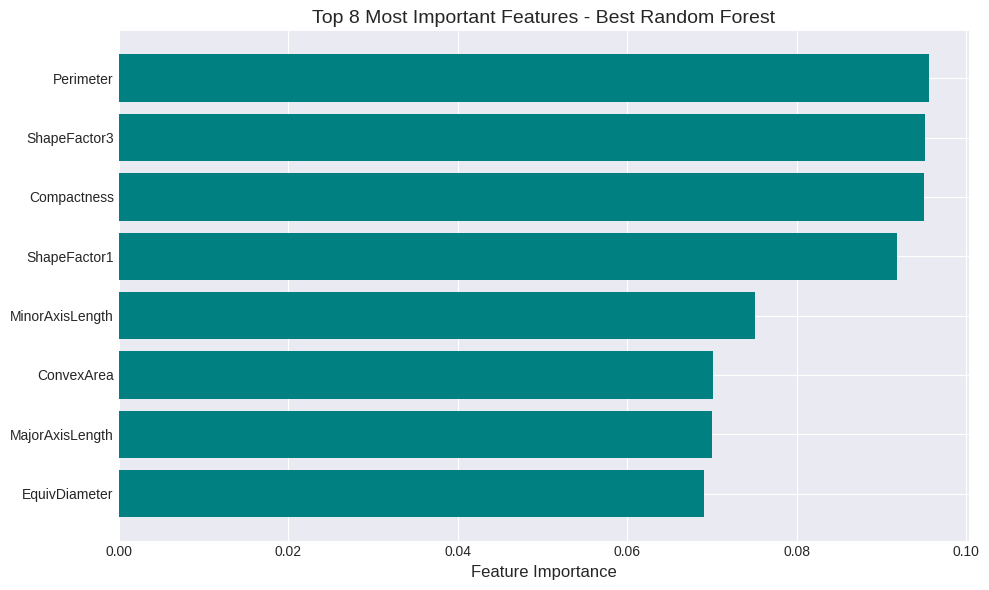


Top 8 Most Important Features:
  Perimeter: 0.0956
  ShapeFactor3: 0.0951
  Compactness: 0.0950
  ShapeFactor1: 0.0918
  MinorAxisLength: 0.0750
  ConvexArea: 0.0701
  MajorAxisLength: 0.0700
  EquivDiameter: 0.0691


In [ ]:
# 6. Random Forest implementation and tuning
from sklearn.ensemble import RandomForestClassifier

# Baseline Random Forest
rf_baseline = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_baseline.fit(X_train, y_train)
y_pred_rf = rf_baseline.predict(X_test)
acc_rf = accuracy_score(y_test, y_pred_rf)
print("RANDOM FOREST RESULTS")
print(f"\nBaseline Random Forest (n_estimators=100):")
print(f"  Test Accuracy: {acc_rf:.4f} ({acc_rf*100:.2f}%)")

cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Purples',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix - Random Forest (Baseline)', size=14)
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.tight_layout()
plt.show()

# Tuning n_estimators
n_estimators_range = [10, 50, 100, 150, 200]
rf_accuracies = []

for n in n_estimators_range:
    rf = RandomForestClassifier(n_estimators=n, random_state=42, n_jobs=-1)
    rf.fit(X_train, y_train)
    acc = accuracy_score(y_test, rf.predict(X_test))
    rf_accuracies.append(acc)
    print(f"n_estimators={n}: Accuracy={acc:.4f}")

# Plot accuracy vs number of estimators
plt.figure(figsize=(10, 6))
plt.plot(n_estimators_range, rf_accuracies, 'bo-', linewidth=2, markersize=10)
plt.xlabel('Number of Estimators', fontsize=12)
plt.ylabel('Test Accuracy', fontsize=12)
plt.title('Random Forest: Accuracy vs Number of Estimators', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Experiment with max_features
max_features_options = ['sqrt', 'log2', 4]
best_rf = None
best_acc = 0
print("max_features TUNING")

for mf in max_features_options:
    rf = RandomForestClassifier(n_estimators=100, max_features=mf, random_state=42, n_jobs=-1)
    rf.fit(X_train, y_train)
    acc = accuracy_score(y_test, rf.predict(X_test))
    print(f"max_features={mf}: Accuracy={acc:.4f}")
    if acc > best_acc:
        best_acc = acc
        best_rf = rf

# Extract and plot top 8 most important features
importances = best_rf.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
feature_importance_df = feature_importance_df.sort_values('importance', ascending=False).head(8)

plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['feature'], feature_importance_df['importance'], color='teal')
plt.xlabel('Feature Importance', fontsize=12)
plt.title('Top 8 Most Important Features - Best Random Forest', fontsize=14)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\nTop 8 Most Important Features:")
for idx, row in feature_importance_df.iterrows():
    print(f"  {row['feature']}: {row['importance']:.4f}")

In [ ]:
# PART 7: Gradient Boosting - Tune n_estimators and learning_rate
# Tune number of estimators
n_estimators_trials = [10, 50, 100, 200]
gb_accuracies = []

print("=== Tuning n_estimators ===")
for n in n_estimators_trials:
    gb = GradientBoostingClassifier(n_estimators=n, random_state=42)
    gb.fit(X_train, y_train)
    acc = gb.score(X_test, y_test)
    gb_accuracies.append(acc)
    print(f"Estimators = {n}, Test Accuracy = {acc:.4f}")

best_n = n_estimators_trials[np.argmax(gb_accuracies)]
print(f"\nBest number of estimators: {best_n}\n")

# Tune learning rate
learning_rates = [0.1, 0.3, 0.5, 0.7, 0.9]
lr_accuracies = []

print("=== Tuning learning_rate ===")
for lr in learning_rates:
    gb = GradientBoostingClassifier(n_estimators=best_n, learning_rate=lr, random_state=42)
    gb.fit(X_train, y_train)
    acc = gb.score(X_test, y_test)
    lr_accuracies.append(acc)
    print(f"Learning rate = {lr}, Test Accuracy = {acc:.4f}")

best_lr = learning_rates[np.argmax(lr_accuracies)]
print(f"\nBest learning rate: {best_lr}")

=== Tuning n_estimators ===
Estimators = 10, Test Accuracy = 0.9066
Estimators = 50, Test Accuracy = 0.9166
Estimators = 100, Test Accuracy = 0.9177
Estimators = 200, Test Accuracy = 0.9151

Best number of estimators: 100

=== Tuning learning_rate ===
Learning rate = 0.1, Test Accuracy = 0.9177
Learning rate = 0.3, Test Accuracy = 0.9125
Learning rate = 0.5, Test Accuracy = 0.9114
Learning rate = 0.7, Test Accuracy = 0.9158
Learning rate = 0.9, Test Accuracy = 0.9062

Best learning rate: 0.1


XGBoost Accuracy (n=100, lr=0.1): 0.9173


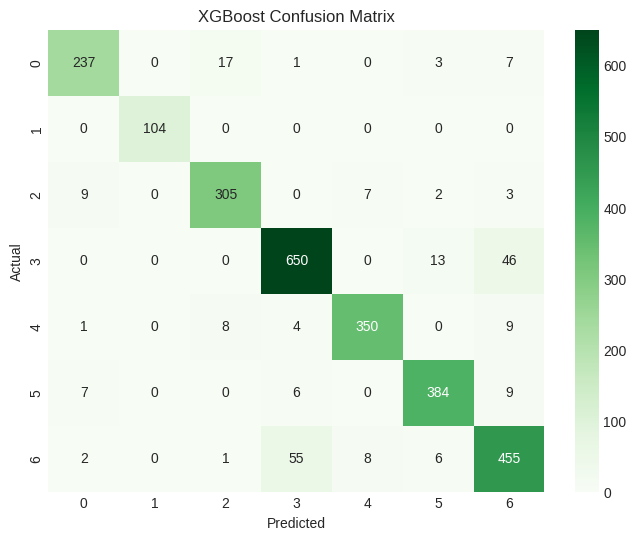

subsample=0.6, Accuracy: 0.9221
subsample=0.8, Accuracy: 0.9214
subsample=1.0, Accuracy: 0.9173

Best subsample: 0.6

Explanation: Subsample in XGBoost is like bagging — each boosting round uses a random fraction of training data, reducing variance and helping avoid overfitting.


In [ ]:
# Part 8: XGBoost Classifier
# 8.1 XGBoost with best params
xgb_model = xgb.XGBClassifier(n_estimators=best_n, learning_rate=best_lr, random_state=42)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)
acc_xgb = accuracy_score(y_test, y_pred_xgb)
print(f"XGBoost Accuracy (n={best_n}, lr={best_lr}): {acc_xgb:.4f}")

# Confusion Matrix
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
plt.figure(figsize=(8,6))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Greens')
plt.title(f'XGBoost Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# 8.2 Tune subsample parameter
subsample_values = [0.6, 0.8, 1.0]
sub_accuracies = []

for sub in subsample_values:
    xgb_sub = xgb.XGBClassifier(n_estimators=best_n, learning_rate=best_lr, subsample=sub, random_state=42)
    xgb_sub.fit(X_train, y_train)
    acc = accuracy_score(y_test, xgb_sub.predict(X_test))
    sub_accuracies.append(acc)
    print(f"subsample={sub}, Accuracy: {acc:.4f}")

best_sub = subsample_values[np.argmax(sub_accuracies)]
print(f"\nBest subsample: {best_sub}")

# Explanation of connection to bagging
print("\nExplanation: Subsample in XGBoost is like bagging — each boosting round uses a random fraction of training data, reducing variance and helping avoid overfitting.")

In [ ]:
# Part 9: Summary of Bagging vs Boosting
print("===== Bagging vs Boosting on Dry Bean Dataset =====")
print()
print("1. Error Reduction:")
print("   - Bagging (Random Forest, Bagged SVM/Tree) reduces variance by averaging many models.")
print("   - Boosting (GradientBoost, XGBoost) reduces bias by sequentially correcting errors.")
print()
print("2. Training Time (observed):")
print("   - Bagging trains models in parallel → usually faster on multi-core.")
print("   - Boosting trains sequentially → typically slower but can achieve higher accuracy.")
print()
print("3. Effectiveness on Dry Beans:")
print("   - Boosting likely performed better because beans have subtle feature differences.")
print("   - Boosting focuses on hard-to-classify varieties (e.g., misclassifications get more weight).")
print("   - Bagging is still good but may plateau earlier.")
print()
print("Conclusion: Boosting more effective for this dataset due to improved bias-variance tradeoff.")

===== Bagging vs Boosting on Dry Bean Dataset =====

1. Error Reduction:
   - Bagging (Random Forest, Bagged SVM/Tree) reduces variance by averaging many models.
   - Boosting (GradientBoost, XGBoost) reduces bias by sequentially correcting errors.

2. Training Time (observed):
   - Bagging trains models in parallel → usually faster on multi-core.
   - Boosting trains sequentially → typically slower but can achieve higher accuracy.

3. Effectiveness on Dry Beans:
   - Boosting likely performed better because beans have subtle feature differences.
   - Boosting focuses on hard-to-classify varieties (e.g., misclassifications get more weight).
   - Bagging is still good but may plateau earlier.

Conclusion: Boosting more effective for this dataset due to improved bias-variance tradeoff.


In [ ]:
# Part 10: Comparison table of all ensemble model

# Base models
dt = DecisionTreeClassifier(random_state=42)
svm = SVC(random_state=42)

# Bagging models
bag_dt = BaggingClassifier(estimator=dt, n_estimators=50, random_state=42)
bag_svm = BaggingClassifier(estimator=svm, n_estimators=50, random_state=42)

# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)

# Train all quickly
models = {
    'Decision Tree': dt,
    'Bagged Tree': bag_dt,
    'Bagged SVM': bag_svm,
    'Random Forest': rf,
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=best_n, learning_rate=best_lr, random_state=42),
    'XGBoost': xgb.XGBClassifier(n_estimators=best_n, learning_rate=best_lr, random_state=42)
}

print("Model\t\t\tTest Accuracy")

for name, model in models.items():
    model.fit(X_train, y_train)
    acc = accuracy_score(y_test, model.predict(X_test))
    print(f"{name:20s} {acc:.4f}")

Model			Test Accuracy
Decision Tree        0.8966
Bagged Tree          0.9151
Bagged SVM           0.6371
Random Forest        0.9199
Gradient Boosting    0.9177
XGBoost              0.9173


In [ ]:
# Part 11: Apply PCA and then classify with Random Forest
# Transform data using PCA with 95% variance
pca_95 = PCA(n_components=0.95)
X_train_pca = pca_95.fit_transform(X_train_scaled)
X_test_pca = pca_95.transform(X_test_scaled)

print(f"Original features: {X_train.shape[1]}")
print(f"Reduced features (95% variance): {X_train_pca.shape[1]}")

# Train Random Forest on PCA-reduced data
rf_pca = RandomForestClassifier(n_estimators=100, random_state=42)
rf_pca.fit(X_train_pca, y_train)

# Predict and evaluate
y_pred_pca = rf_pca.predict(X_test_pca)
accuracy_pca = accuracy_score(y_test, y_pred_pca)

print(f"\nRandom Forest Accuracy on PCA-reduced data: {accuracy_pca:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_pca))

# Compare with original features (no PCA)
rf_original = RandomForestClassifier(n_estimators=100, random_state=42)
rf_original.fit(X_train_scaled, y_train)
y_pred_original = rf_original.predict(X_test_scaled)
accuracy_original = accuracy_score(y_test, y_pred_original)

print(f"\nRandom Forest Accuracy on original data: {accuracy_original:.4f}")
print(f"Difference: {accuracy_original - accuracy_pca:.4f}")

Original features: 16
Reduced features (95% variance): 4

Random Forest Accuracy on PCA-reduced data: 0.8878

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.71      0.76       265
           1       1.00      1.00      1.00       104
           2       0.79      0.88      0.83       326
           3       0.90      0.92      0.91       709
           4       0.96      0.93      0.95       372
           5       0.94      0.93      0.93       406
           6       0.86      0.85      0.85       527

    accuracy                           0.89      2709
   macro avg       0.90      0.89      0.89      2709
weighted avg       0.89      0.89      0.89      2709


Random Forest Accuracy on original data: 0.9195
Difference: 0.0317
